In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import scipy
import xarray as xr
import numpy as np
import os

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.size'] = 14

In [2]:
ds_list = []
ds_list_jja = []
p_dict = {
    'action_mode': [],
    'tg_threshold': [], 
    'water_tank_size': [],
}
outputpath='../data/water_tank_eval/'
ref_dsf = '/home/junjie/github/UrbSprIrr/data/workdir/outputfolder/lnd/hist/roofsp_raw.clm2.h0.2006-01-01-00000.nc'
ref_ds = xr.open_dataset(ref_dsf)
ref_ds['time'] = ref_ds['time'].dt.round('min') + np.timedelta64(9, 'h')  
ref_ds = ref_ds.sel(time=slice('2010', '2019'), column=1)
ref_ds_jja = ref_ds.sel(time=(ref_ds['time.month']>=6) & (ref_ds['time.month']<=9))
for f in os.listdir(outputpath):
    f1 = outputpath + f
    ds = xr.open_dataset(f1)
    ds['time'] = ds['time'].dt.round('min') + np.timedelta64(9, 'h')
    ds = ds.sel(time=slice('2010', '2019'), column=1)
    exp0 = float(f.split('_')[2])
    exp1 = float(f.split('_')[3])
    exp2 = float(f.split('_')[4].split('.nc')[0])
    
    ds_list.append(ds)
    ds_list_jja.append(ds.sel(time=(ds['time.month']>=6) & (ds['time.month']<=9)))
    p_dict['action_mode'].append(exp0)
    p_dict['tg_threshold'].append(exp1)
    p_dict['water_tank_size'].append(exp2)

rwts_dict = {
    p_dict['water_tank_size'][i]: ds_list[i] for i in range(len(ds_list))
}
rwts_dict_jja = {
    p_dict['water_tank_size'][i]: ds_list_jja[i] for i in range(len(ds_list_jja))
}

In [3]:
#rain = ref_ds['RAIN'].groupby('time.year').sum('time')*(1800)
# rain = ref_ds_jja['RAIN'].groupby('time.year').mean('time')*(1800)
# ac = ds_list_jja[0]['URBAN_AC'].groupby('time.year').mean('time')
# ac_ref = ref_ds_jja['URBAN_AC'].groupby('time.year').mean('time')
# ac_diff = ac - ac_ref

In [4]:
def get_plot_data(rwts_dict, ref_ds, var, ax):
    colors = plt.get_cmap('Blues')(np.linspace(0, 1, len(rwts_dict)+2))
    i=0
    rwts = np.array(list(rwts_dict.keys()))
    rwts.sort()
    df = pd.DataFrame()
    for w in rwts:
        if var in ['Tair']:
            rain = ref_ds[var].groupby('time.year').mean('time') - 273.15
        elif var in ['RAIN']:
            rain = ref_ds[var].groupby('time.year').sum('time')*(1800)
        else:
            rain = ref_ds[var].groupby('time.year').mean('time') 
        ac = rwts_dict[w]['URBAN_AC'].groupby('time.year').mean('time')
        ac_ref = ref_ds['URBAN_AC'].groupby('time.year').mean('time')
        ac_diff = ac - ac_ref
        ax.scatter(rain.values, ac_diff.values, color=colors[i])
        
        # Fit a linear model
        X = sm.add_constant(rain.values)
        model = sm.OLS(ac_diff.values, X)
        results = model.fit()
        
        # Get the model results
        a0 = results.params[0]
        a1 = results.params[1]
        p_value = results.pvalues[1]
        
        x = rain.values
        y = a0 + a1 * x
        ax.plot(x, y, color=colors[i+2])
        
        spearmanr, _ = scipy.stats.spearmanr(rain.values, ac_diff.values)
        
        # Get the R2
        r2 = results.rsquared
        
        df = pd.concat([df, pd.DataFrame({'rwts': [w], 'slope': [a1], 'intercept': [a0], 
                                         'p_value': [p_value], 'r2': [r2], 'spearmanr': [spearmanr]})])
        
        i+=1
    
    return df

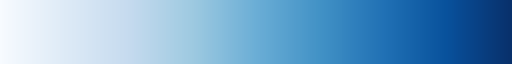

In [5]:
plt.get_cmap('Blues')

,rwts,slope,intercept,p_value,r2,spearmanr,var
0,1.03,-0.01,0.16,0.48,0.07,-0.18,Tair
0,3.02,-0.02,0.41,0.25,0.16,-0.20,Tair
0,5.08,-0.03,0.55,0.20,0.19,-0.19,Tair
0,7.08,-0.04,0.75,0.15,0.25,-0.24,Tair
0,9.13,-0.04,0.96,0.10,0.31,-0.30,Tair
0,11.14,-0.05,1.20,0.06,0.38,-0.38,Tair
0,13.07,-0.06,1.29,0.05,0.39,-0.45,Tair
0,15.21,-0.06,1.34,0.06,0.38,-0.45,Tair
0,17.14,-0.07,1.44,0.04,0.43,-0.59,Tair
0,19.30,-0.07,1.50,0.04,0.44,-0.52,Tair


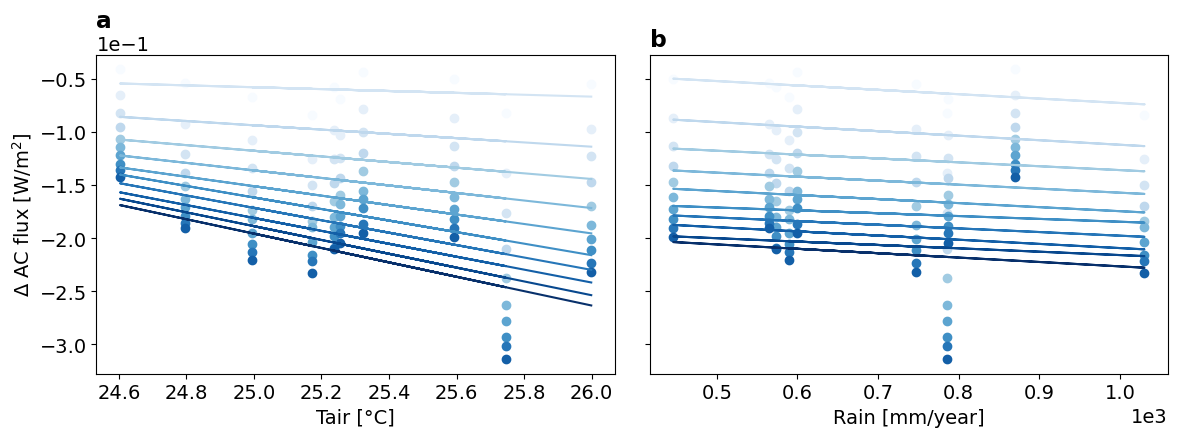

In [ ]:
plt.figure(figsize=(12, 8))
df = pd.DataFrame()
i = 0
titles = ['a', 'b', 'c', 'd']
xlabels = ['Rain [mm/year]', 'Tair [°C]', 'Qair [kg/kg]', 'LWdown [W/m$^2$]']

xlabels = ['Tair [°C]', 'Rain [mm/year]', 'Tair [°C]']

vars = [ 'Tair', 'RAIN',]
for var in vars:
    ax = plt.subplot(2, 2, i+1)
    _df = get_plot_data(rwts_dict_jja, ref_ds_jja, var, ax)
    ax.set_xlabel(xlabels[i])
    if i % 2 == 0:  # Only set ylabel for the leftmost plots
        ax.set_ylabel('$\Delta$ AC flux [W/m$^2$]')
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    else:
        ax.set_yticklabels([])
    ax.set_title(titles[i], loc='left', fontweight='bold')
    i += 1
    # data
    _df['var'] = var
    df = pd.concat([df, _df])
    
    if var in ['RAIN', 'Qair']:
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

display(df.round(2))
plt.tight_layout()
plt.savefig('../data/figs/background_climate.pdf', dpi=300, bbox_inches='tight')
plt.show()